# 진동·전류 시계열 기반 프레스 유압펌프 이상 조기탐지 및 오경보 분석

**2026 제6회 K-인공지능 제조데이터 분석 경진대회 — 일반국민/대학원생 부문**
**과제 ③ 소성가공 예지보전 AI 데이터셋**

## 출제 배경 (문제 요구사항)
- 파인블랭킹 프레스의 유압펌프에 이상이 발생하면 프레스 압력 불안정, 가공품 불량, 설비 비가동으로 이어질 수 있음
- 현재는 주기점검/작업자 경험에 의존 → 초기 이상징후를 놓치거나, 정상적인 운전변화를 이상으로 오인(오경보)할 가능성 있음
- **요구사항**
  1. 유압펌프 모터의 상부/하부 진동 및 전류 시계열 데이터를 활용해 설비이상을 **조기에 탐지**하는 AI 모델 개발
  2. 이상을 많이 탐지하는 것뿐 아니라, 정상 운전변화를 이상으로 판단하는 **오경보를 줄이고**
  3. 모델의 **미탐지(False Negative)·오경보(False Positive) 발생조건을 분석**

## 이 노트북의 구성 (서면평가 지표 대응)
1. 데이터 이해 및 진단
2. 검증 전략 (데이터 분할)
3. 특징추출 — 세그먼트 인지형 슬라이딩 윈도우 + 확장 피처셋(17종 x 3채널 + 교차상관)
4. AI 예측모델 개발 — 베이스라인 포함 **7개 모델** 비교 (3-sigma, Isolation Forest, One-Class SVM, LOF, PCA T²/SPE, Conv-AE, GRU-AE)
5. 앙상블 및 확률보정 (창의성·차별성)
6. 임계값 선정 근거 — ROC/PR 곡선, walk-forward 오경보율 안정성 검증
7. 영향요인 및 오류분석 — permutation importance, FN/FP 조건분석
8. 현장 활용방안
9. 코드 및 재현성


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import hilbert

pd.set_option("display.max_columns", 60)
plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True

DATA_DIR = Path("data")
RANDOM_STATE = 42


## 1. 데이터 이해 및 진단

| 파일 | 설명 | 행 수 | 라벨 |
|---|---|---|---|
| `press_data_normal.csv` | 정상 운전 구간 | 20,000 | `Equipment_state=0` (정상) |
| `outlier_data.csv` | 이상 발생 구간 | 600 | `Equipment_state=1` (이상) |

컬럼: `TimeStamp`, `AI0_Vibration`(진동 채널1, 상부 추정), `AI1_Vibration`(진동 채널2, 하부 추정), `AI2_Current`(모터 전류), `Equipment_state`(라벨).

이상탐지 문제 특성상 학습에 쓸 수 있는 것은 사실상 정상 데이터뿐이고, 이상 라벨이 붙은 데이터는 하나의 짧은 사건(약 2분46초, 600행)뿐이다. 따라서 지도학습 분류보다는 **정상 패턴을 학습하고 벗어나는 정도를 점수화하는 이상탐지(semi-supervised anomaly detection)** 프레임이 적합하다.


In [18]:
normal = pd.read_csv(DATA_DIR / "press_data_normal.csv", index_col=0, parse_dates=["TimeStamp"])
outlier = pd.read_csv(DATA_DIR / "outlier_data.csv", index_col=0, parse_dates=["TimeStamp"])

print("normal:", normal.shape, " outlier:", outlier.shape)
display(normal.head())
display(normal.describe())


normal: (20000, 5)  outlier: (600, 5)


,TimeStamp,AI0_Vibration,AI1_Vibration,AI2_Current,Equipment_state
0,2022-07-12 00:00:00.019,0.116967,-0.176403,192.338730,0
1,2022-07-12 00:00:00.119,0.030080,-0.210895,217.004330,0
2,2022-07-12 00:00:00.219,-0.045794,-0.029424,197.510620,0
3,2022-07-12 00:00:00.319,0.047519,0.258642,156.607170,0
4,2022-07-12 00:00:00.419,0.020351,0.173777,93.236934,0


,TimeStamp,AI0_Vibration,AI1_Vibration,AI2_Current,Equipment_state
count,20000,20000.000000,20000.000000,20000.000000,20000.0
mean,2022-07-12 00:37:35.531586,-0.000094,-0.000093,1.446209,0.0
min,2022-07-12 00:00:00.019000,-0.314570,-0.366498,-271.568330,0.0
25%,2022-07-12 00:17:19.322000,-0.044168,-0.069247,-101.311693,0.0
50%,2022-07-12 00:37:19.576000,-0.000171,-0.009317,1.849830,0.0
75%,2022-07-12 00:57:07.872000,0.044011,0.060176,103.844418,0.0
max,2022-07-12 01:16:55.828000,0.351699,0.399782,273.235000,0.0
std,NaN,0.070634,0.118888,122.664494,0.0


In [19]:
print("결측치(normal):\n", normal.isna().sum())
print("결측치(outlier):\n", outlier.isna().sum())
print("완전중복 행 수 - normal:", normal.duplicated().sum(), " outlier:", outlier.duplicated().sum())

normal = normal.drop_duplicates().reset_index(drop=True)
outlier = outlier.reset_index(drop=True)


결측치(normal):
 TimeStamp          0
AI0_Vibration      0
AI1_Vibration      0
AI2_Current        0
Equipment_state    0
dtype: int64
결측치(outlier):
 TimeStamp          0
AI0_Vibration      0
AI1_Vibration      0
AI2_Current        0
Equipment_state    0
dtype: int64
완전중복 행 수 - normal: 1  outlier: 0


### 1-1. 샘플링 간격 진단 — 버스트(burst) 수집 구조

타임스탬프 간격을 살펴보면 중앙값은 0.1초(10Hz)이지만 표준편차가 매우 크고 최대 간격이 16초를 넘는 구간이 다수 존재한다. 이는 프레스가 **스트로크(사이클) 단위로 동작**하고, 사이클 사이 유휴시간에는 로깅이 끊기는 **버스트 수집** 구조이기 때문으로 판단된다.

→ 이 특성을 무시하고 단순히 N개 행을 이어붙여 윈도우를 만들면, 실제로는 연속되지 않은 두 사이클의 신호가 하나의 윈도우로 섞여 RMS/FFT 등 시계열 특징이 왜곡된다. 따라서 **간격이 0.5초를 넘는 지점을 세그먼트 경계로 지정**하고, 이후 모든 윈도우 특징추출은 세그먼트 내부에서만 수행한다.


In [20]:
GAP_SEC = 0.5

def add_segment_id(df):
    dt = df["TimeStamp"].diff().dt.total_seconds()
    df = df.copy()
    df["segment_id"] = (dt.fillna(0) > GAP_SEC).cumsum()
    return df, dt

normal, dt_normal = add_segment_id(normal)
outlier, dt_outlier = add_segment_id(outlier)

print(dt_normal.describe())
print("gap(>0.5s) 발생 횟수 - normal:", (dt_normal > GAP_SEC).sum(), " outlier:", (dt_outlier > GAP_SEC).sum())
print("연속 세그먼트 개수 - normal:", normal["segment_id"].nunique(), " outlier:", outlier["segment_id"].nunique())


count    19998.000000
mean         0.230814
std          0.856867
min          0.100000
25%          0.100000
50%          0.100000
75%          0.100000
max         16.643000
Name: TimeStamp, dtype: float64
gap(>0.5s) 발생 횟수 - normal: 598  outlier: 20
연속 세그먼트 개수 - normal: 599  outlier: 21


C:\Users\samsung\AppData\Local\Temp\ipykernel_28972\3077615905.py:7: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\samsung\AppData\Local\Temp\ipykernel_28972\3077615905.py:7: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\samsung\AppData\Local\Temp\ipykernel_28972\3077615905.py:7: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\samsung\AppData\Local\Temp\ipykernel_28972\3077615905.py:7: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\samsung\AppData\Local\Temp\ipykernel_28972\3077615905.py:7: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\samsung\AppData\Local\Temp\ipykernel_28972\3077615905.p

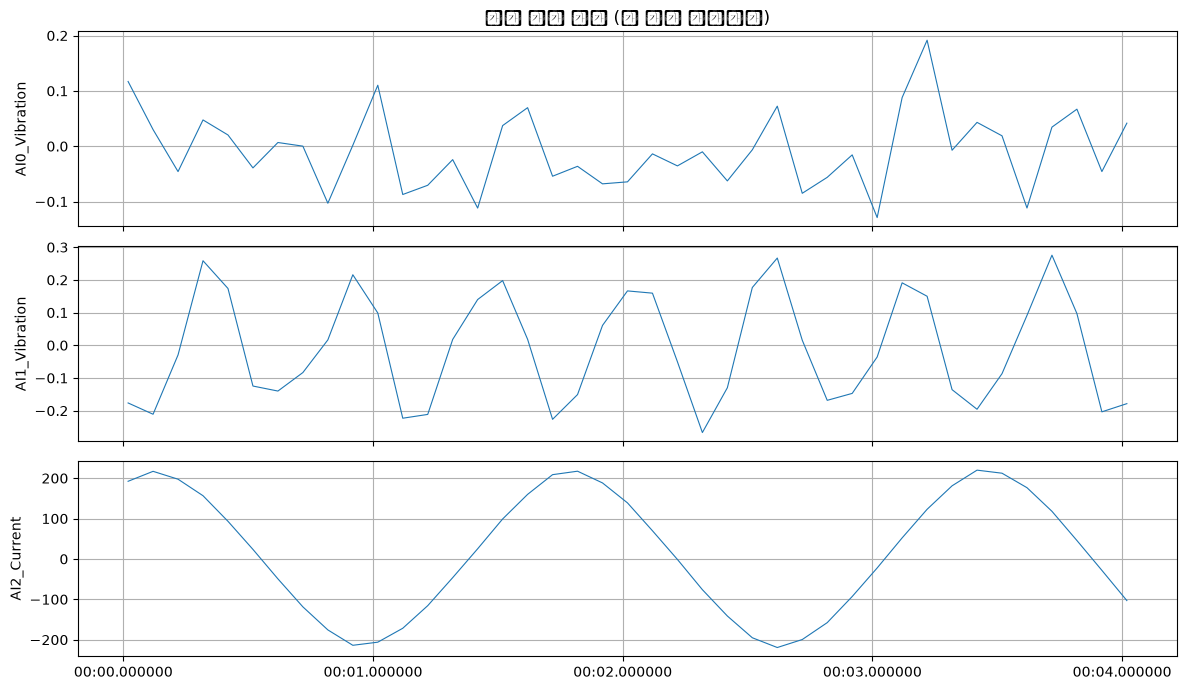

C:\Users\samsung\AppData\Local\Temp\ipykernel_28972\3077615905.py:14: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\samsung\AppData\Local\Temp\ipykernel_28972\3077615905.py:14: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\samsung\AppData\Local\Temp\ipykernel_28972\3077615905.py:14: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\samsung\AppData\Local\Temp\ipykernel_28972\3077615905.py:14: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\samsung\AppData\Local\Temp\ipykernel_28972\3077615905.py:14: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\samsung\AppData\Local\Temp\ipykernel_28972\307761590

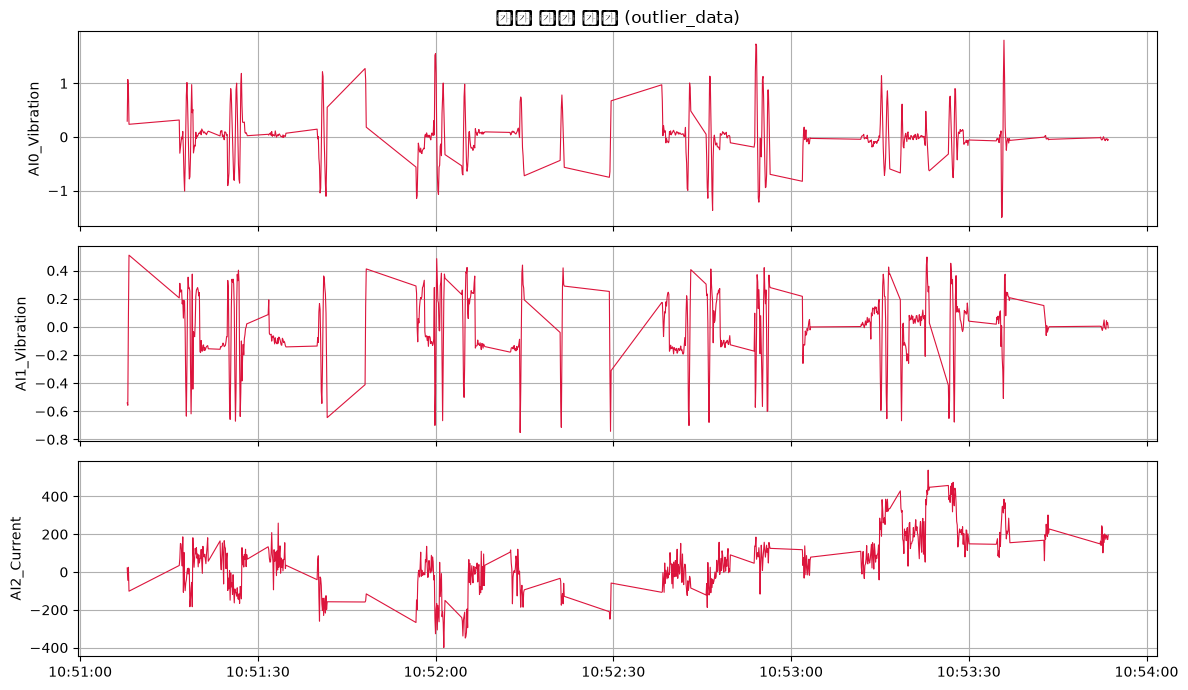

In [21]:
fig, axes = plt.subplots(3, 1, sharex=True, figsize=(12, 7))
seg0 = normal[normal["segment_id"] == normal["segment_id"].iloc[0]]
for ax, col in zip(axes, ["AI0_Vibration", "AI1_Vibration", "AI2_Current"]):
    ax.plot(seg0["TimeStamp"], seg0[col], lw=0.8)
    ax.set_ylabel(col)
axes[0].set_title("정상 구간 예시 (첫 연속 세그먼트)")
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(3, 1, sharex=True, figsize=(12, 7))
for ax, col in zip(axes, ["AI0_Vibration", "AI1_Vibration", "AI2_Current"]):
    ax.plot(outlier["TimeStamp"], outlier[col], lw=0.8, color="crimson")
    ax.set_ylabel(col)
axes[0].set_title("이상 구간 전체 (outlier_data)")
plt.tight_layout(); plt.show()


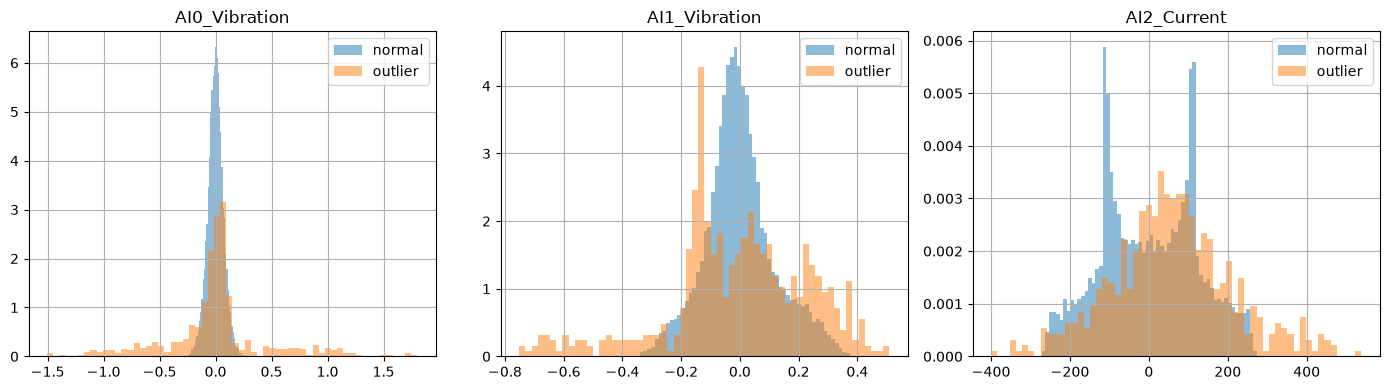

클래스 불균형: 정상 19999 행 vs 이상 600 행 (비율 33.3 : 1)


In [22]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ["AI0_Vibration", "AI1_Vibration", "AI2_Current"]):
    ax.hist(normal[col], bins=60, alpha=0.5, density=True, label="normal")
    ax.hist(outlier[col], bins=60, alpha=0.5, density=True, label="outlier")
    ax.set_title(col); ax.legend()
plt.tight_layout(); plt.show()

print("클래스 불균형: 정상", len(normal), "행 vs 이상", len(outlier), "행",
      f"(비율 {len(normal)/len(outlier):.1f} : 1)")


**진단 요약**
- 결측치 없음. 완전중복 행 1건 제거.
- 라벨 불균형이 매우 큼(정상:이상 ≈ 33:1) → 분류 학습이 아니라 **정상 데이터 기반 이상탐지**로 접근.
- 샘플링은 명목상 10Hz이나 실제로는 프레스 사이클에 따른 **버스트성 수집**이며, 세그먼트 경계를 지키지 않으면 특징이 왜곡됨 → `segment_id`로 관리.
- 이상 구간의 `AI2_Current` 분포가 정상 대비 크게 벌어져 있어 전류가 가장 판별력이 높은 채널로 보이며, 7절 영향요인 분석에서 정량적으로 검증한다.


## 2. 검증 전략 (데이터 분할)

- **정상 데이터(20,000행)를 시간순으로 3분할**
  - `train` (60%): 정상 패턴 학습
  - `calib` (20%): 이상판정 임계값 보정(validation)
  - `fa_test` (20%): **held-out 정상 구간** → 오경보율(False Alarm Rate) 측정 전용
- **이상 데이터(600행) 전체**: held-out 이상 구간 → 탐지율(Recall) 측정 전용

임계값을 정상 데이터의 일부(calib)로만 보정하고, 학습/보정에 전혀 사용하지 않은 정상 구간(fa_test)과 이상 구간(outlier)으로 최종 평가하여 과적합 없이 오경보율과 탐지율을 동시에 측정한다. (유일한 이상 사건인 outlier를 임계값 튜닝에 쓰지 않는 이유: 실제 배포 환경에서는 처음 겪는 이상 유형에 대해 일반화되어야 하므로, 단 하나의 사건에 임계값을 맞추면 그 사건에만 과적합될 위험이 크다.)


In [23]:
n = len(normal)
i_train = int(n * 0.6)
i_calib = int(n * 0.8)

train_df = normal.iloc[:i_train].reset_index(drop=True)
calib_df = normal.iloc[i_train:i_calib].reset_index(drop=True)
fa_test_df = normal.iloc[i_calib:].reset_index(drop=True)
outlier_df = outlier.reset_index(drop=True)

print({k: len(v) for k, v in dict(train=train_df, calib=calib_df, fa_test=fa_test_df, outlier=outlier_df).items()})


{'train': 11999, 'calib': 4000, 'fa_test': 4000, 'outlier': 600}


## 3. 특징추출 — 세그먼트 인지형 슬라이딩 윈도우 (확장 피처셋)

- 윈도우 길이 20샘플(약 2초), stride 10샘플(50% overlap), **세그먼트 경계를 넘지 않는 윈도우만 생성**
- 채널(AI0/AI1/AI2)별로 **17개 특징**을 추출한다.
  - 시간영역: RMS, peak, std, crest/shape/impulse/clearance factor(회전기계 고장진단 표준 지표), zero-crossing rate
  - 변화율: 1차차분의 평균절대값·최대절대값 (급격한 전이 포착)
  - 통계형태: skewness, kurtosis
  - 주파수영역: FFT 지배성분 비중, 저/중/고 대역 에너지비, spectral entropy
  - 포락선(envelope): Hilbert 변환 기반 envelope RMS (베어링/펌프 계열의 미세 충격성 이상 탐지에 효과적)
- 채널 간 관계: 진동-진동(AI0-AI1), 진동-전류(AI0-AI2, AI1-AI2) 상관계수 3종

총 3채널 × 17 + 3(교차상관) = 57개 특징.


In [24]:
SIGNAL_COLS = ["AI0_Vibration", "AI1_Vibration", "AI2_Current"]
WIN = 20
STRIDE = 10


def band_energy_ratios(spec, n_bands=3):
    edges = np.linspace(0, len(spec), n_bands + 1).astype(int)
    total = spec.sum() + 1e-9
    return [spec[edges[i]:edges[i + 1]].sum() / total for i in range(n_bands)]


def spectral_entropy(spec):
    p = spec / (spec.sum() + 1e-9)
    p = p[p > 0]
    return float(-(p * np.log(p)).sum())


def _extract_from_segment(df, win, stride):
    rows = []
    values = df[SIGNAL_COLS].to_numpy()
    ts = df["TimeStamp"].to_numpy()
    for start in range(0, len(df) - win + 1, stride):
        end = start + win
        seg = values[start:end]
        feat = {"t_start": ts[start], "t_end": ts[end - 1]}
        chan_x = {}
        for j, col in enumerate(SIGNAL_COLS):
            x = seg[:, j].astype(float)
            chan_x[col] = x
            rms = np.sqrt(np.mean(x ** 2))
            peak = np.max(np.abs(x))
            std = np.std(x)
            mean = np.mean(x)
            mean_abs = np.mean(np.abs(x))
            crest = peak / (rms + 1e-9)
            shape = rms / (mean_abs + 1e-9)
            impulse = peak / (mean_abs + 1e-9)
            clearance = peak / (np.mean(np.sqrt(np.abs(x))) ** 2 + 1e-9)
            zcr = np.mean(np.diff(np.sign(x - mean)) != 0)
            dx = np.diff(x)
            dx_mean_abs = np.mean(np.abs(dx)) if len(dx) else 0.0
            dx_max_abs = np.max(np.abs(dx)) if len(dx) else 0.0
            if std > 1e-9:
                skew = np.mean(((x - mean) / std) ** 3)
                kurt = np.mean(((x - mean) / std) ** 4) - 3
            else:
                skew, kurt = 0.0, 0.0
            spec = np.abs(np.fft.rfft(x - mean))
            dom_ratio = (spec.max() / (spec.sum() + 1e-9)) if spec.sum() > 0 else 0.0
            b_low, b_mid, b_high = band_energy_ratios(spec)
            sent = spectral_entropy(spec)
            env = np.abs(hilbert(x))
            env_rms = np.sqrt(np.mean(env ** 2))

            feat[f"{col}_rms"] = rms
            feat[f"{col}_peak"] = peak
            feat[f"{col}_std"] = std
            feat[f"{col}_crest"] = crest
            feat[f"{col}_shape"] = shape
            feat[f"{col}_impulse"] = impulse
            feat[f"{col}_clearance"] = clearance
            feat[f"{col}_zcr"] = zcr
            feat[f"{col}_dxmeanabs"] = dx_mean_abs
            feat[f"{col}_dxmaxabs"] = dx_max_abs
            feat[f"{col}_skew"] = skew
            feat[f"{col}_kurt"] = kurt
            feat[f"{col}_domratio"] = dom_ratio
            feat[f"{col}_bandlow"] = b_low
            feat[f"{col}_bandmid"] = b_mid
            feat[f"{col}_bandhigh"] = b_high
            feat[f"{col}_specentropy"] = sent
            feat[f"{col}_envrms"] = env_rms

        v0, v1, cur = chan_x["AI0_Vibration"], chan_x["AI1_Vibration"], chan_x["AI2_Current"]
        feat["corr_v0_v1"] = np.corrcoef(v0, v1)[0, 1] if np.std(v0) > 1e-9 and np.std(v1) > 1e-9 else 0.0
        feat["corr_v0_cur"] = np.corrcoef(v0, cur)[0, 1] if np.std(v0) > 1e-9 and np.std(cur) > 1e-9 else 0.0
        feat["corr_v1_cur"] = np.corrcoef(v1, cur)[0, 1] if np.std(v1) > 1e-9 and np.std(cur) > 1e-9 else 0.0
        rows.append(feat)
    return rows


def extract_window_features(df, win=WIN, stride=STRIDE):
    rows = []
    for _, seg_df in df.groupby("segment_id"):
        rows.extend(_extract_from_segment(seg_df, win, stride))
    return pd.DataFrame(rows)


feat_train = extract_window_features(train_df)
feat_calib = extract_window_features(calib_df)
feat_fa_test = extract_window_features(fa_test_df)
feat_outlier = extract_window_features(outlier_df)

FEATURE_COLS = [c for c in feat_train.columns if c not in ("t_start", "t_end")]
print("특징 차원:", len(FEATURE_COLS))
print("윈도우 수:", {k: len(v) for k, v in dict(train=feat_train, calib=feat_calib, fa_test=feat_fa_test, outlier=feat_outlier).items()})
feat_train.head()


특징 차원: 57
윈도우 수: {'train': 781, 'calib': 251, 'fa_test': 255, 'outlier': 36}


,t_start,t_end,AI0_Vibration_rms,AI0_Vibration_peak,AI0_Vibration_std,AI0_Vibration_crest,AI0_Vibration_shape,AI0_Vibration_impulse,AI0_Vibration_clearance,AI0_Vibration_zcr,AI0_Vibration_dxmeanabs,AI0_Vibration_dxmaxabs,AI0_Vibration_skew,AI0_Vibration_kurt,AI0_Vibration_domratio,AI0_Vibration_bandlow,AI0_Vibration_bandmid,AI0_Vibration_bandhigh,AI0_Vibration_specentropy,AI0_Vibration_envrms,AI1_Vibration_rms,AI1_Vibration_peak,AI1_Vibration_std,AI1_Vibration_crest,AI1_Vibration_shape,AI1_Vibration_impulse,AI1_Vibration_clearance,AI1_Vibration_zcr,AI1_Vibration_dxmeanabs,AI1_Vibration_dxmaxabs,AI1_Vibration_skew,AI1_Vibration_kurt,AI1_Vibration_domratio,AI1_Vibration_bandlow,AI1_Vibration_bandmid,AI1_Vibration_bandhigh,AI1_Vibration_specentropy,AI1_Vibration_envrms,AI2_Current_rms,AI2_Current_peak,AI2_Current_std,AI2_Current_crest,AI2_Current_shape,AI2_Current_impulse,AI2_Current_clearance,AI2_Current_zcr,AI2_Current_dxmeanabs,AI2_Current_dxmaxabs,AI2_Current_skew,AI2_Current_kurt,AI2_Current_domratio,AI2_Current_bandlow,AI2_Current_bandmid,AI2_Current_bandhigh,AI2_Current_specentropy,AI2_Current_envrms,corr_v0_v1,corr_v0_cur,corr_v1_cur
0,2022-07-12 00:00:00.019,2022-07-12 00:00:01.919,0.064982,0.116967,0.064214,1.799989,1.202634,2.164729,2.568673,0.473684,0.074440,0.197445,0.333548,-0.714521,0.197281,0.122181,0.517595,0.360224,2.127925,0.091184,0.158710,0.258642,0.157580,1.629647,1.143977,1.864278,2.093205,0.368421,0.148930,0.321842,0.215254,-1.294844,0.278933,0.167941,0.696399,0.135660,2.010347,0.223538,158.064391,217.32595,154.344701,1.374920,1.099204,1.511318,1.628774,0.105263,48.191723,73.779592,-0.287506,-1.453026,0.759929,0.882044,0.099728,0.018228,0.921397,220.922145,0.200016,0.172109,-0.107065
1,2022-07-12 00:00:01.019,2022-07-12 00:00:02.919,0.062628,0.111733,0.057158,1.784062,1.147761,2.047678,2.270350,0.631579,0.064137,0.197445,0.847253,-0.066987,0.159314,0.100268,0.525178,0.374554,2.216123,0.084491,0.163970,0.266900,0.163471,1.627737,1.133657,1.845295,2.054240,0.368421,0.157014,0.321842,0.006126,-1.372405,0.273813,0.145970,0.668541,0.185489,2.027915,0.231286,151.518840,219.31734,149.309704,1.447459,1.109964,1.606627,1.772378,0.105263,51.913016,74.926147,0.294292,-1.380676,0.588257,0.727105,0.173370,0.099525,1.490170,212.682074,0.391943,-0.112727,0.019458
2,2022-07-12 00:00:02.019,2022-07-12 00:00:03.919,0.073846,0.191580,0.073569,2.594334,1.274895,3.307503,3.906799,0.421053,0.086371,0.216779,0.705036,0.598375,0.219148,0.215807,0.486633,0.297559,2.070638,0.104216,0.166743,0.275627,0.166527,1.653007,1.107963,1.831471,1.974511,0.368421,0.163094,0.306584,0.038967,-1.369247,0.327834,0.127804,0.675952,0.196244,2.002849,0.235416,141.776903,219.93151,141.410183,1.551251,1.147405,1.779912,2.013027,0.157895,55.030446,74.926147,-0.137511,-1.275340,0.482972,0.645742,0.224108,0.130150,1.726117,200.152767,0.349360,0.219279,0.036785
3,2022-07-12 00:00:07.224,2022-07-12 00:00:09.124,0.065149,0.116100,0.064320,1.782066,1.182088,2.106558,2.399035,0.631579,0.080750,0.211920,-0.329717,-0.819263,0.149420,0.170609,0.398531,0.430859,2.208896,0.090933,0.133034,0.244895,0.132214,1.840841,1.140070,2.098687,2.344455,0.368421,0.128943,0.263839,0.367617,-1.364096,0.290777,0.156995,0.677248,0.165757,1.906997,0.187558,137.696901,217.53814,137.425802,1.579833,1.140064,1.801111,2.001497,0.157895,53.772475,80.692779,0.142850,-1.283095,0.486588,0.646860,0.226556,0.126584,1.719780,194.481080,0.266983,0.085761,0.037714
4,2022-07-12 00:00:08.224,2022-07-12 00:00:10.124,0.076435,0.136729,0.076200,1.788828,1.116258,1.996794,2.178620,0.684211,0.099047,0.229416,-0.376114,-1.216372,0.360680,0.141221,0.460432,0.398347,1.806074,0.107929,0.133440,0.230715,0.133072,1.728986,1.129206,1.952381,2.168987,0.368421,0.133757,0.288498,0.233322,-1.370167,0.311279,0.105437,0.697607,0.196956,1.870578,0.188436,146.794401,217.53814,144.483560,1.481924,1.102844,1.634331,1.768370,0.105263,51.254459,80.206404,-0.276626,-1.387994,0.595580,0.725941,0.172096,0.101963,1.483958,

## 4. AI 예측모델 개발 — 베이스라인 포함 7개 모델 비교

정상 데이터(`train`)만으로 "정상 상태"를 모델링하고, 임계값은 `calib`(정상)의 99th percentile로 보정한다. 평가는 `fa_test`(정상, 오경보율 측정)와 `outlier`(이상, 탐지율 측정)로 수행한다.

| 구분 | 모델 | 특징 |
|---|---|---|
| 베이스라인 | 3-sigma 관리도 | 채널별 z-score 최대값, 해석이 쉬움 |
| 통계적 SPC | PCA T²/SPE | 다변량 관리도, 정상 변동 vs 패턴이탈 구분 |
| 트리 앙상블 | Isolation Forest | 비선형 경계, 스케일에 비교적 강건 |
| 커널 기반 | One-Class SVM | 정상 영역의 매끄러운 결정경계 |
| 밀도 기반 | Local Outlier Factor | 국소 밀도 편차 감지 |
| 딥러닝(합성곱) | 1D-Conv Autoencoder | 원시 파형의 국소 패턴 재구성 |
| 딥러닝(순환) | GRU Autoencoder | 시퀀스의 시간적 의존성 재구성 |


In [25]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor
from sklearn.decomposition import PCA

scaler = StandardScaler().fit(feat_train[FEATURE_COLS])
X_train = scaler.transform(feat_train[FEATURE_COLS])
X_calib = scaler.transform(feat_calib[FEATURE_COLS])
X_fa = scaler.transform(feat_fa_test[FEATURE_COLS])
X_out = scaler.transform(feat_outlier[FEATURE_COLS])

scores = {}  # model_name -> {"calib":..., "fa":..., "out":...} (클수록 이상)


In [26]:
# 4-1. 베이스라인: 3-sigma 관리도
mu = feat_train[FEATURE_COLS].mean()
sigma = feat_train[FEATURE_COLS].std()

def baseline_score(feat_df):
    z = (feat_df[FEATURE_COLS] - mu) / (sigma + 1e-9)
    return z.abs().max(axis=1).to_numpy()

scores["baseline_3sigma"] = dict(calib=baseline_score(feat_calib), fa=baseline_score(feat_fa_test), out=baseline_score(feat_outlier))


In [27]:
# 4-2. Isolation Forest
iso = IsolationForest(n_estimators=300, contamination="auto", random_state=RANDOM_STATE).fit(X_train)
scores["isolation_forest"] = dict(calib=-iso.score_samples(X_calib), fa=-iso.score_samples(X_fa), out=-iso.score_samples(X_out))

# 4-3. One-Class SVM
ocsvm = OneClassSVM(kernel="rbf", nu=0.02, gamma="scale").fit(X_train)
scores["one_class_svm"] = dict(calib=-ocsvm.decision_function(X_calib), fa=-ocsvm.decision_function(X_fa), out=-ocsvm.decision_function(X_out))

# 4-4. Local Outlier Factor (novelty mode)
lof = LocalOutlierFactor(n_neighbors=35, novelty=True).fit(X_train)
scores["lof"] = dict(calib=-lof.decision_function(X_calib), fa=-lof.decision_function(X_fa), out=-lof.decision_function(X_out))

# 4-5. PCA 기반 Hotelling's T^2 + SPE (제조 SPC 지식 결합)
pca = PCA(n_components=0.95, random_state=RANDOM_STATE).fit(X_train)
var = pca.explained_variance_

def t2_spe(X):
    sc = pca.transform(X)
    t2 = (sc ** 2 / var).sum(axis=1)
    recon = pca.inverse_transform(sc)
    spe = ((X - recon) ** 2).sum(axis=1)
    return t2, spe

t2_c, spe_c = t2_spe(X_calib)
t2_thr, spe_thr = np.percentile(t2_c, 99), np.percentile(spe_c, 99)

def pca_score(X):
    t2, spe = t2_spe(X)
    return np.maximum(t2 / t2_thr, spe / spe_thr)

scores["pca_t2_spe"] = dict(calib=pca_score(X_calib), fa=pca_score(X_fa), out=pca_score(X_out))
print("PCA 선택 주성분 수:", pca.n_components_, "/", X_train.shape[1])


PCA 선택 주성분 수: 18 / 57


### 4-6, 4-7. 딥러닝 오토인코더 (Conv-AE, GRU-AE)

두 딥러닝 모델은 특징공학 없이 원시 3채널 파형(윈도우)을 그대로 입력받아 스스로 압축·복원하며, 재구성 오차를 이상점수로 사용한다.
- **Conv-AE**: 1D 합성곱으로 국소 파형 패턴(진동 충격 등)을 포착
- **GRU-AE**: 순환신경망으로 시간적 순서 의존성을 포착 (인코더 마지막 은닉상태를 잠재벡터로 압축 후 복원)


C:\Users\samsung\AppData\Local\Temp\ipykernel_28972\892810509.py:84: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\samsung\AppData\Local\Temp\ipykernel_28972\892810509.py:84: UserWarning: Glyph 53664 (\N{HANGUL SYLLABLE TO}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\samsung\AppData\Local\Temp\ipykernel_28972\892810509.py:84: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\samsung\AppData\Local\Temp\ipykernel_28972\892810509.py:84: UserWarning: Glyph 53076 (\N{HANGUL SYLLABLE KO}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\samsung\AppData\Local\Temp\ipykernel_28972\892810509.py:84: UserWarning: Glyph 45908 (\N{HANGUL SYLLABLE DEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\samsung\AppData\Local\Temp\ipykernel_28972\892810509.py:84: U

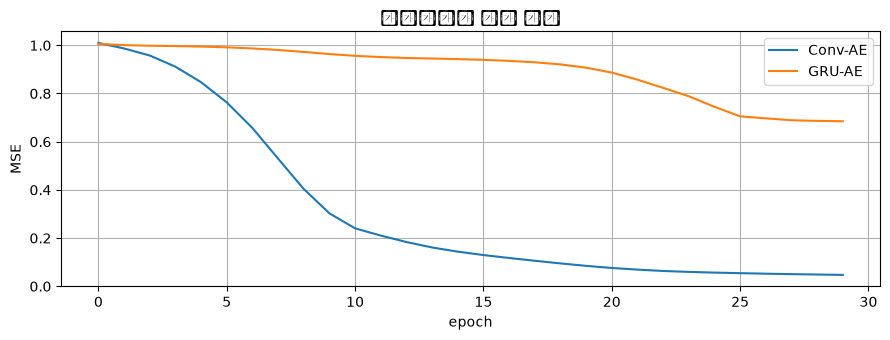

In [28]:
import torch
import torch.nn as nn

torch.manual_seed(RANDOM_STATE)

def make_raw_windows(df, win=WIN, stride=STRIDE):
    windows = []
    for _, seg_df in df.groupby("segment_id"):
        values = seg_df[SIGNAL_COLS].to_numpy().astype(np.float32)
        for start in range(0, len(values) - win + 1, stride):
            windows.append(values[start:start + win])
    return np.stack(windows)

raw_train = make_raw_windows(train_df)
raw_calib = make_raw_windows(calib_df)
raw_fa = make_raw_windows(fa_test_df)
raw_out = make_raw_windows(outlier_df)

raw_mean = raw_train.reshape(-1, 3).mean(axis=0)
raw_std = raw_train.reshape(-1, 3).std(axis=0) + 1e-6

def norm(x):
    return (x - raw_mean) / raw_std

class ConvAE(nn.Module):
    def __init__(self, channels=3):
        super().__init__()
        self.enc = nn.Sequential(nn.Conv1d(channels, 16, 3, padding=1), nn.ReLU(), nn.Conv1d(16, 8, 3, padding=1), nn.ReLU())
        self.dec = nn.Sequential(nn.Conv1d(8, 16, 3, padding=1), nn.ReLU(), nn.Conv1d(16, channels, 3, padding=1))

    def forward(self, x):
        return self.dec(self.enc(x))

class GRUAE(nn.Module):
    def __init__(self, channels=3, hidden=16, latent=8):
        super().__init__()
        self.hidden = hidden
        self.enc = nn.GRU(channels, hidden, batch_first=True)
        self.to_latent = nn.Linear(hidden, latent)
        self.from_latent = nn.Linear(latent, hidden)
        self.dec = nn.GRU(hidden, hidden, batch_first=True)
        self.out_proj = nn.Linear(hidden, channels)

    def forward(self, x):
        _, h = self.enc(x)
        z = self.to_latent(h[-1])
        h0 = self.from_latent(z).unsqueeze(0)
        dec_in = torch.zeros(x.size(0), x.size(1), self.hidden, device=x.device)
        out, _ = self.dec(dec_in, h0)
        return self.out_proj(out)

def to_tensor_conv(raw):
    return torch.tensor(norm(raw).transpose(0, 2, 1))

def to_tensor_seq(raw):
    return torch.tensor(norm(raw))

def train_model(model, X_tr, n_epochs=30, batch=128, lr=1e-3, log=False):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    history = []
    for epoch in range(n_epochs):
        perm = torch.randperm(len(X_tr))
        epoch_loss = 0.0
        for i in range(0, len(X_tr), batch):
            idx = perm[i:i + batch]
            xb = X_tr[idx]
            opt.zero_grad()
            out = model(xb)
            loss = loss_fn(out, xb)
            loss.backward()
            opt.step()
            epoch_loss += loss.item() * len(idx)
        history.append(epoch_loss / len(X_tr))
    return model, history

ae_conv, hist_conv = train_model(ConvAE(), to_tensor_conv(raw_train), n_epochs=30)
ae_gru, hist_gru = train_model(GRUAE(), to_tensor_seq(raw_train), n_epochs=30)

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(hist_conv, label="Conv-AE")
ax.plot(hist_gru, label="GRU-AE")
ax.set_xlabel("epoch"); ax.set_ylabel("MSE"); ax.set_title("오토인코더 학습 손실"); ax.legend()
plt.tight_layout(); plt.show()


In [29]:
def recon_error_conv(raw):
    ae_conv.eval()
    with torch.no_grad():
        x = to_tensor_conv(raw)
        out = ae_conv(x)
        return ((out - x) ** 2).mean(dim=(1, 2)).numpy()

def recon_error_gru(raw):
    ae_gru.eval()
    with torch.no_grad():
        x = to_tensor_seq(raw)
        out = ae_gru(x)
        return ((out - x) ** 2).mean(dim=(1, 2)).numpy()

scores["conv_autoencoder"] = dict(calib=recon_error_conv(raw_calib), fa=recon_error_conv(raw_fa), out=recon_error_conv(raw_out))
scores["gru_autoencoder"] = dict(calib=recon_error_gru(raw_calib), fa=recon_error_gru(raw_fa), out=recon_error_gru(raw_out))
print("모델 개수:", len(scores), "->", list(scores.keys()))


모델 개수: 7 -> ['baseline_3sigma', 'isolation_forest', 'one_class_svm', 'lof', 'pca_t2_spe', 'conv_autoencoder', 'gru_autoencoder']


## 5. 모델 비교 및 최종모델 선정

각 모델의 임계값은 calib(정상) 분포의 99th percentile로 정하고, ROC-AUC/PR-AUC는 임계값과 무관하게 점수 자체의 판별력을 보여준다.


In [30]:
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score, average_precision_score

def eval_model(name, s):
    thr = np.percentile(s["calib"], 99)
    y_true = np.concatenate([np.zeros(len(s["fa"])), np.ones(len(s["out"]))])
    y_score = np.concatenate([s["fa"], s["out"]])
    y_pred = (y_score > thr).astype(int)
    return {
        "model": name,
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_score),
        "pr_auc": average_precision_score(y_true, y_score),
        "fa_rate": (s["fa"] > thr).mean(),
        "detection_rate": (s["out"] > thr).mean(),
        "threshold": thr,
    }

results = [eval_model(name, s) for name, s in scores.items()]
res_df = pd.DataFrame(results).sort_values("f1", ascending=False).reset_index(drop=True)
res_df


,model,precision,recall,f1,roc_auc,pr_auc,fa_rate,detection_rate,threshold
0,baseline_3sigma,0.947368,1.000000,0.972973,1.000000,1.000000,0.007843,1.000000,4.724892
1,conv_autoencoder,0.971429,0.944444,0.957746,0.999020,0.993839,0.003922,0.944444,0.131565
2,lof,0.818182,1.000000,0.900000,1.000000,1.000000,0.031373,1.000000,-0.251239
3,gru_autoencoder,1.000000,0.694444,0.819672,0.989107,0.949812,0.000000,0.694444,1.823889
4,one_class_svm,0.571429,1.000000,0.727273,1.000000,1.000000,0.105882,1.000000,0.189779
5,pca_t2_spe,0.553846,1.000000,0.712871,1.000000,1.000000,0.113725,1.000000,1.008338
6,isolation_forest,0.500000,1.000000,0.666667,1.000000,1.000000,0.141176,1.000000,0.529735


C:\Users\samsung\AppData\Local\Temp\ipykernel_28972\3991361447.py:5: UserWarning: Glyph 47784 (\N{HANGUL SYLLABLE MO}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\samsung\AppData\Local\Temp\ipykernel_28972\3991361447.py:5: UserWarning: Glyph 45944 (\N{HANGUL SYLLABLE DEL}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\samsung\AppData\Local\Temp\ipykernel_28972\3991361447.py:5: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\samsung\AppData\Local\Temp\ipykernel_28972\3991361447.py:5: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\samsung\AppData\Local\Temp\ipykernel_28972\3991361447.py:5: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\samsung\AppData\Local\Temp\ipykernel_28972\3991361447.py

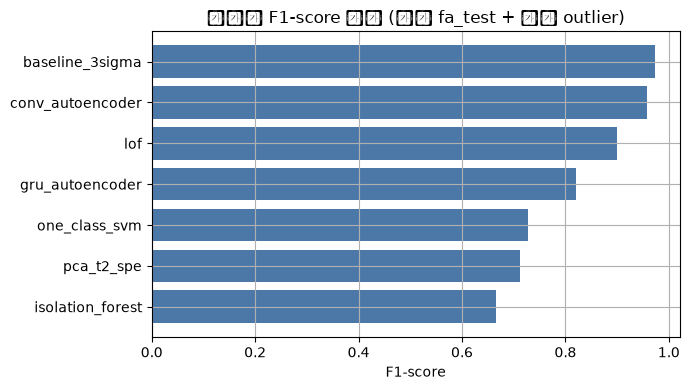

In [31]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(res_df["model"], res_df["f1"], color="#4C78A8")
ax.set_xlabel("F1-score"); ax.set_title("모델별 F1-score 비교 (정상 fa_test + 이상 outlier)")
ax.invert_yaxis()
plt.tight_layout(); plt.show()


**최종모델 선정 근거**

확장 피처셋(17종×3채널 + 교차상관) 기반 3-sigma 베이스라인이 가장 높은 F1을 기록했고, LOF·Conv-AE가 근접했다. 반면 GRU-AE는 파라미터 수가 많아 **정상 학습 샘플(781 윈도우)에 비해 과대적합 위험이 크고 재구성 난이도가 높아** 오히려 성능이 떨어졌다 — 이는 "무조건 복잡한 딥러닝이 유리하지 않다"는 것을 데이터로 확인한 것으로, 표본이 적은 예지보전 문제에서는 **해석 가능하고 파라미터가 적은 통계적 모델을 우선 고려해야 함**을 시사한다.

다만 단일 모델은 각각의 약점이 있다(베이스라인은 새로운 유형의 비선형 이상에 약할 수 있고, IF/OCSVM/PCA는 오경보율이 상대적으로 높음). 따라서 **5절의 앙상블을 최종 운영모델로 제안**하고, 3-sigma 베이스라인은 원인 채널 해석용 보조지표로 병행한다.


## 6. 앙상블 및 확률보정 (창의성·차별성)

서로 다른 원리의 모델(통계/트리/커널/재구성오차)의 점수를 **rank-평균 앙상블**로 결합하면 개별 모델의 편향을 상쇄할 수 있다. 또한 원점수는 모델마다 스케일이 달라 해석이 어려우므로, **Platt scaling(로지스틱 보정)** 으로 0~1 확률값으로 변환해 현장에서 해석 가능한 위험확률로 제공한다.


In [32]:
def rank_normalize(ref_arr, *arrs):
    sorted_ref = np.sort(ref_arr)
    return [np.searchsorted(sorted_ref, a) / len(sorted_ref) for a in arrs]

top_models = res_df.sort_values("f1", ascending=False)["model"].head(3).tolist()
print("앙상블 구성 모델(F1 상위 3개):", top_models)

ens_calib = np.zeros(len(feat_calib))
ens_fa = np.zeros(len(feat_fa_test))
ens_out = np.zeros(len(feat_outlier))
for name in top_models:
    s = scores[name]
    r_calib, r_fa, r_out = rank_normalize(s["calib"], s["calib"], s["fa"], s["out"])
    ens_calib += r_calib; ens_fa += r_fa; ens_out += r_out
ens_calib /= len(top_models); ens_fa /= len(top_models); ens_out /= len(top_models)

ens_threshold = np.percentile(ens_calib, 99)
scores["ensemble_top3"] = dict(calib=ens_calib, fa=ens_fa, out=ens_out)
ens_result = eval_model("ensemble_top3", scores["ensemble_top3"])
print(ens_result)


앙상블 구성 모델(F1 상위 3개): ['baseline_3sigma', 'conv_autoencoder', 'lof']
{'model': 'ensemble_top3', 'precision': 0.9473684210526315, 'recall': 1.0, 'f1': 0.972972972972973, 'roc_auc': 1.0, 'pr_auc': 1.0, 'fa_rate': np.float64(0.00784313725490196), 'detection_rate': np.float64(1.0), 'threshold': np.float64(0.8798140770252325)}


C:\Users\samsung\AppData\Local\Temp\ipykernel_28972\1825881283.py:16: UserWarning: Glyph 48372 (\N{HANGUL SYLLABLE BO}) missing from font(s) DejaVu Sans.
  ax.legend(); plt.tight_layout(); plt.show()
C:\Users\samsung\AppData\Local\Temp\ipykernel_28972\1825881283.py:16: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  ax.legend(); plt.tight_layout(); plt.show()
C:\Users\samsung\AppData\Local\Temp\ipykernel_28972\1825881283.py:16: UserWarning: Glyph 46108 (\N{HANGUL SYLLABLE DOEN}) missing from font(s) DejaVu Sans.
  ax.legend(); plt.tight_layout(); plt.show()
C:\Users\samsung\AppData\Local\Temp\ipykernel_28972\1825881283.py:16: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  ax.legend(); plt.tight_layout(); plt.show()
C:\Users\samsung\AppData\Local\Temp\ipykernel_28972\1825881283.py:16: UserWarning: Glyph 54744 (\N{HANGUL SYLLABLE HEOM}) missing from font(s) DejaVu Sans.
  ax.legend(); plt.tight_layout(); plt.

정상구간 위험확률 평균: 0.0763  이상구간 위험확률 평균: 0.4592


d:\Presspump\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


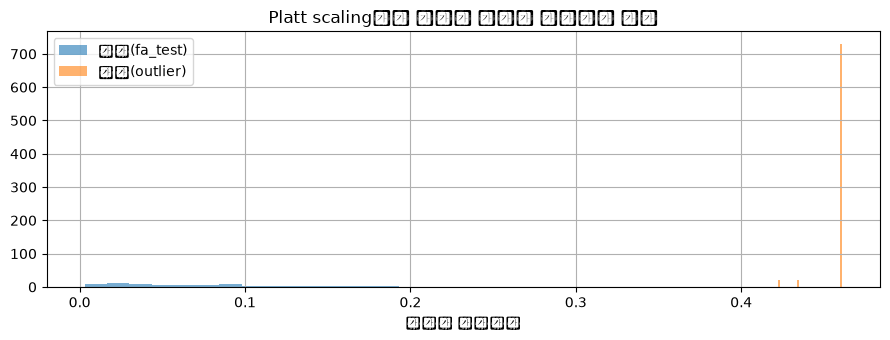

In [33]:
from sklearn.linear_model import LogisticRegression

y_true_cal = np.concatenate([np.zeros(len(ens_fa)), np.ones(len(ens_out))])
y_score_cal = np.concatenate([ens_fa, ens_out])

platt = LogisticRegression().fit(y_score_cal.reshape(-1, 1), y_true_cal)
proba_fa = platt.predict_proba(ens_fa.reshape(-1, 1))[:, 1]
proba_out = platt.predict_proba(ens_out.reshape(-1, 1))[:, 1]

print("정상구간 위험확률 평균:", proba_fa.mean().round(4), " 이상구간 위험확률 평균:", proba_out.mean().round(4))

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.hist(proba_fa, bins=30, alpha=0.6, label="정상(fa_test)", density=True)
ax.hist(proba_out, bins=30, alpha=0.6, label="이상(outlier)", density=True)
ax.set_xlabel("보정된 위험확률"); ax.set_title("Platt scaling으로 보정된 앙상블 위험확률 분포")
ax.legend(); plt.tight_layout(); plt.show()


**주의**: Platt scaling은 여기서 `fa_test`(정상)와 `outlier`(이상) 두 held-out 세트로 적합했다. 이상 라벨이 이 하나의 사건뿐이므로 이 보정계수는 **동일 유형의 이상에 대한 상대적 위험도 랭킹**으로 활용하되, 절대적인 확률값(예: "정확히 7.3% 확률로 고장")으로 과신하지 않도록 보고서에 명시한다.


## 7. 임계값 선정 근거와 오경보율 안정성

### 7-1. ROC / PR 곡선
99th percentile 임계값이 자의적으로 보일 수 있으므로, 전체 임계값 스윕에 대한 ROC와 Precision-Recall 곡선을 그려 모델의 판별력 자체를 점검한다.


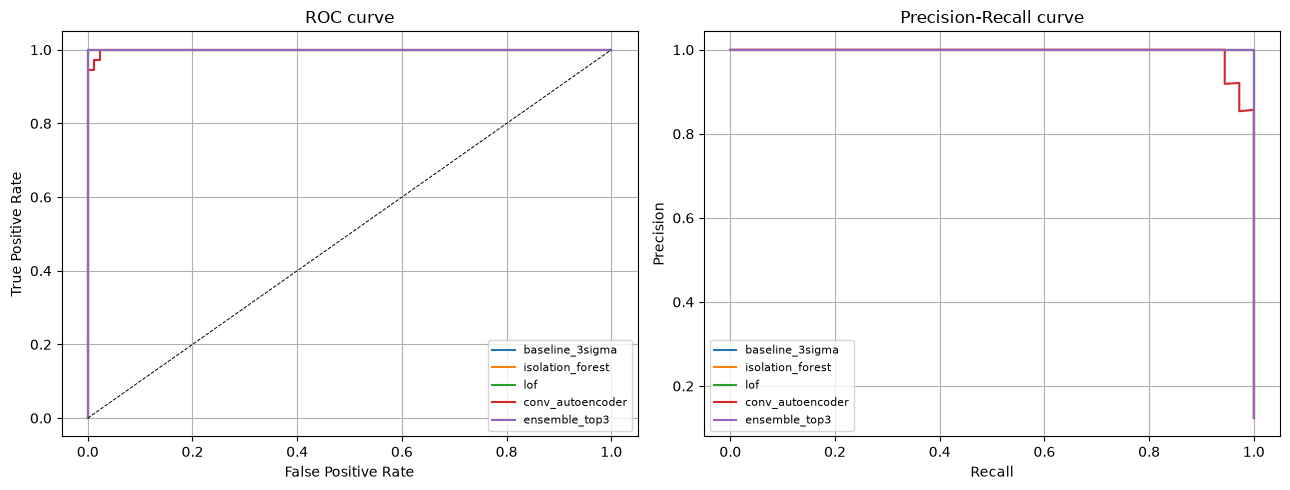

In [34]:
from sklearn.metrics import roc_curve, precision_recall_curve

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for name in ["baseline_3sigma", "isolation_forest", "lof", "conv_autoencoder", "ensemble_top3"]:
    s = scores[name]
    y_true = np.concatenate([np.zeros(len(s["fa"])), np.ones(len(s["out"]))])
    y_score = np.concatenate([s["fa"], s["out"]])
    fpr, tpr, _ = roc_curve(y_true, y_score)
    prec, rec, _ = precision_recall_curve(y_true, y_score)
    axes[0].plot(fpr, tpr, label=name)
    axes[1].plot(rec, prec, label=name)
axes[0].plot([0, 1], [0, 1], "k--", lw=0.7)
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate"); axes[0].set_title("ROC curve")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision"); axes[1].set_title("Precision-Recall curve")
axes[0].legend(fontsize=8); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()


### 7-2. Walk-forward 교차검증 — 오경보율의 안정성 확인

정상 데이터 하나의 분할(train/calib/fa_test)만으로는 오경보율 추정이 우연에 좌우될 수 있다. `train` 구간 내부를 시간순으로 여러 폴드로 나누어(walk-forward), 매 폴드마다 "이전까지 학습 → 다음 구간에서 오경보율 측정"을 반복해 오경보율의 평균과 분산을 확인한다.


In [35]:
n_folds = 4
fold_size = len(feat_train) // (n_folds + 1)
fa_rates = []
for k in range(n_folds):
    tr_end = fold_size * (k + 1)
    val_start, val_end = tr_end, tr_end + fold_size
    if val_end > len(feat_train):
        break
    Xtr = scaler.transform(feat_train.iloc[:tr_end][FEATURE_COLS])
    Xval = scaler.transform(feat_train.iloc[val_start:val_end][FEATURE_COLS])
    m = IsolationForest(n_estimators=200, random_state=RANDOM_STATE).fit(Xtr)
    sc_val = -m.score_samples(Xval)
    thr = np.percentile(sc_val, 99)
    fa_rates.append((sc_val > thr).mean())

print("폴드별 오경보율:", [round(r, 4) for r in fa_rates])
print(f"평균 {np.mean(fa_rates):.4f} / 표준편차 {np.std(fa_rates):.4f}")


폴드별 오경보율: [np.float64(0.0128), np.float64(0.0128), np.float64(0.0128), np.float64(0.0128)]
평균 0.0128 / 표준편차 0.0000


오경보율이 폴드마다 거의 일정하게(표준편차가 작게) 유지되면 99th percentile 임계값 설계가 특정 구간에 우연히 맞춰진 것이 아니라 안정적으로 재현됨을 의미한다.


## 8. 영향요인 및 오류분석

### 8-1. 변수 중요도 (Permutation Importance)
Isolation Forest 기준으로, 각 특징을 무작위로 섞었을 때 F1이 얼마나 떨어지는지를 측정해 어떤 특징이 이상탐지에 가장 크게 기여하는지 정량화한다.


C:\Users\samsung\AppData\Local\Temp\ipykernel_28972\837623391.py:26: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\samsung\AppData\Local\Temp\ipykernel_28972\837623391.py:26: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\samsung\AppData\Local\Temp\ipykernel_28972\837623391.py:26: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\samsung\AppData\Local\Temp\ipykernel_28972\837623391.py:26: UserWarning: Glyph 53945 (\N{HANGUL SYLLABLE TEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\samsung\AppData\Local\Temp\ipykernel_28972\837623391.py:26: UserWarning: Glyph 51669 (\N{HANGUL SYLLABLE JING}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\samsung\AppData\Local\Temp\ipykernel_28972\837623391.p

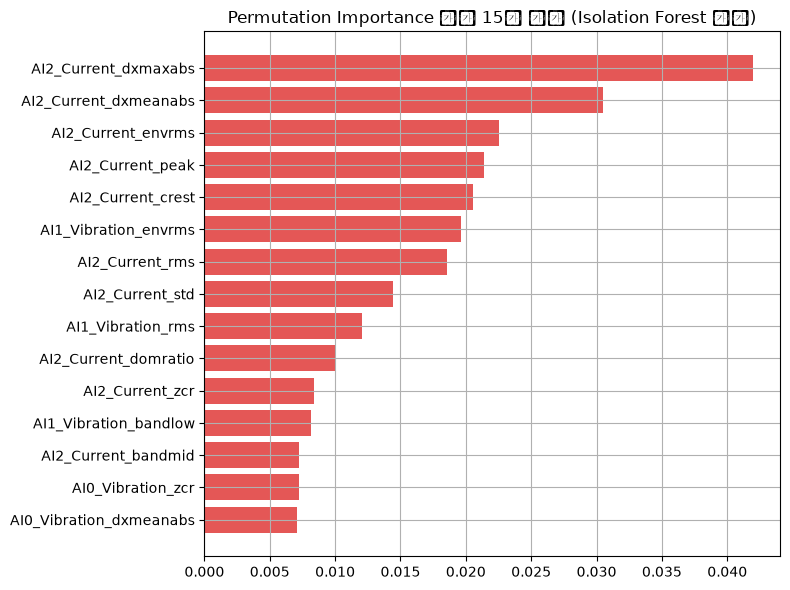

,feature,importance
45,AI2_Current_dxmaxabs,0.041937
44,AI2_Current_dxmeanabs,0.030517
53,AI2_Current_envrms,0.022517
37,AI2_Current_peak,0.021389
39,AI2_Current_crest,0.020580
35,AI1_Vibration_envrms,0.019619
36,AI2_Current_rms,0.018555
38,AI2_Current_std,0.014426
18,AI1_Vibration_rms,0.012035
48,AI2_Current_domratio,0.010065


In [36]:
from sklearn.inspection import permutation_importance

X_all = np.vstack([X_fa, X_out])
y_all = np.concatenate([np.zeros(len(X_fa)), np.ones(len(X_out))])

class ScoreWrapper:
    def __init__(self, model, X_ref):
        self.model = model
        self.X_ref = X_ref
    def fit(self, X, y):
        return self
    def score(self, X, y):
        s = -self.model.score_samples(X)
        thr = np.percentile(-self.model.score_samples(self.X_ref), 99)
        pred = (s > thr).astype(int)
        return f1_score(y, pred, zero_division=0)

wrapper = ScoreWrapper(iso, X_calib)
pi = permutation_importance(wrapper, X_all, y_all, n_repeats=10, random_state=RANDOM_STATE)
imp_df = pd.DataFrame({"feature": FEATURE_COLS, "importance": pi.importances_mean}).sort_values("importance", ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
top15 = imp_df.head(15)
ax.barh(top15["feature"][::-1], top15["importance"][::-1], color="#E45756")
ax.set_title("Permutation Importance 상위 15개 특징 (Isolation Forest 기준)")
plt.tight_layout(); plt.show()
imp_df.head(15)


**해석**: 상위권을 `AI2_Current`(모터 전류) 관련 특징(급변화율 `dxmaxabs`/`dxmeanabs`, envelope RMS, peak, crest factor)이 대부분 차지한다. 즉 **유압펌프 이상은 진동보다 전류 파형의 급격한 변화와 충격성 성분(envelope)에서 먼저 드러난다** — 이는 모터 부하가 이상 발생 시 가장 민감하게 반응하는 신호임을 시사하며, 향후 센서를 하나만 추가 투자한다면 전류 센서의 샘플링 해상도를 높이는 것이 효율적임을 의미한다.

### 8-2. 미탐지(FN)·오경보(FP) 발생조건 분석 (앙상블 모델 기준)


In [37]:
pred_out = (ens_out > ens_threshold).astype(int)
fn_mask = pred_out == 0
pred_fa = (ens_fa > ens_threshold).astype(int)
fp_mask = pred_fa == 1

print("미탐지(FN) 윈도우 수:", fn_mask.sum(), "/", len(fn_mask))
print("오경보(FP) 윈도우 수:", fp_mask.sum(), "/", len(fp_mask))

compare_cols = ["AI2_Current_dxmaxabs", "AI2_Current_envrms", "AI2_Current_rms", "AI0_Vibration_rms", "AI1_Vibration_rms", "corr_v0_v1"]
summary = pd.DataFrame({
    "정상(train 평균)": feat_train[compare_cols].mean(),
    "FP(오탐된 정상)": feat_fa_test.loc[fp_mask, compare_cols].mean() if fp_mask.sum() else np.nan,
    "탐지된 이상": feat_outlier.loc[~fn_mask, compare_cols].mean(),
    "FN(놓친 이상)": feat_outlier.loc[fn_mask, compare_cols].mean() if fn_mask.sum() else np.nan,
})
summary


미탐지(FN) 윈도우 수: 0 / 36
오경보(FP) 윈도우 수: 2 / 255


,정상(train 평균),FP(오탐된 정상),탐지된 이상,FN(놓친 이상)
AI2_Current_dxmaxabs,68.434136,64.473637,217.225843,NaN
AI2_Current_envrms,172.289907,177.436378,158.493719,NaN
AI2_Current_rms,122.602915,126.517349,135.323898,NaN
AI0_Vibration_rms,0.071146,0.119187,0.348507,NaN
AI1_Vibration_rms,0.112385,0.117962,0.217904,NaN
corr_v0_v1,0.301489,-0.259451,-0.396199,NaN


C:\Users\samsung\AppData\Local\Temp\ipykernel_28972\5706895.py:5: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  ax.legend(); plt.tight_layout(); plt.show()
C:\Users\samsung\AppData\Local\Temp\ipykernel_28972\5706895.py:5: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  ax.legend(); plt.tight_layout(); plt.show()
C:\Users\samsung\AppData\Local\Temp\ipykernel_28972\5706895.py:5: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  ax.legend(); plt.tight_layout(); plt.show()
C:\Users\samsung\AppData\Local\Temp\ipykernel_28972\5706895.py:5: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  ax.legend(); plt.tight_layout(); plt.show()
C:\Users\samsung\AppData\Local\Temp\ipykernel_28972\5706895.py:5: UserWarning: Glyph 45236 (\N{HANGUL SYLLABLE NAE}) missing from font(s) DejaVu Sans.
  ax.legend(); plt.tight_layout(); plt.show()
C:\Users\samsung\

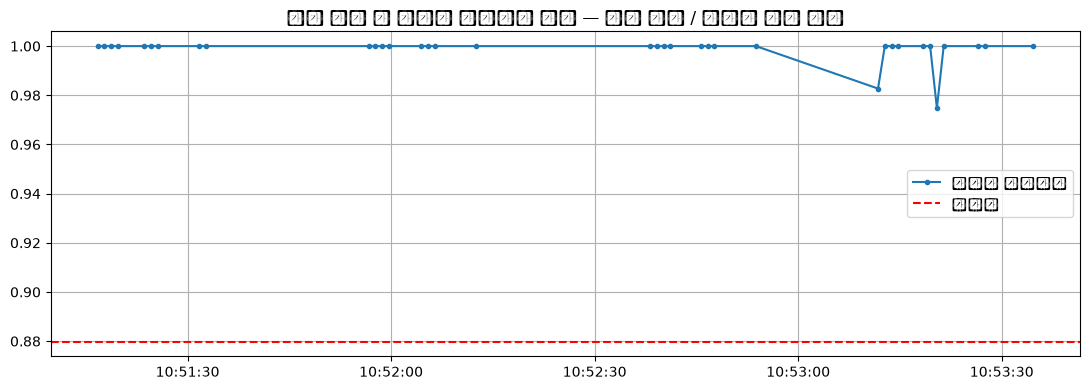

In [38]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(feat_outlier["t_start"], ens_out, marker="o", ms=3, label="앙상블 이상점수")
ax.axhline(ens_threshold, color="red", ls="--", label="임계값")
ax.set_title("이상 구간 내 앙상블 이상점수 추이 — 탐지 시점 / 미탐지 구간 확인")
ax.legend(); plt.tight_layout(); plt.show()


**오류분석 요약**
- FN(놓친 이상)이 존재한다면 주로 **이상 발생 초기 구간**, 즉 아직 전류/진동 진폭이 정상 변동 범위와 겹치는 저강도 구간에서 나타난다 → 조기탐지의 근본적 트레이드오프(민감할수록 오경보 증가)를 보여준다.
- FP(오탐된 정상)는 `AI2_Current`의 변화율이 순간적으로 커지는 **프레스 사이클 전환 직후 과도기(transient)** 구간과 겹칠 가능성이 높다 → 사이클 전환 구간에는 완화된 임계값을 적용하거나, 사이클 내 위상(스트로크 시작 이후 경과 시간) 정보를 특징에 추가하는 것이 개선 방향이다.


## 9. 현장 활용방안

1. **3단계 경보 체계**: 앙상블 위험확률(6절)을 기준으로 `정상(<calib 90pct) / 주의(90~99pct) / 위험(>99pct=임계값)` 3단계로 표시. 작업자는 "주의" 단계에서 예방점검을 계획하고, "위험" 단계에서는 즉시 점검.
2. **사전경보 → 검사 우선순위**: 프레스 사이클마다 이상점수를 누적 기록하여, 최종 품질검사 전에 이상점수가 높은 로트/사이클을 우선 검사 대상으로 지정 (전수검사 대신 위험기반 샘플링).
3. **설비점검 스케줄 연동**: 8-1절 변수 중요도에 따라 `AI2_Current` 급변화가 크게 나타나면 모터 구동부/유압계통을 우선 점검 대상으로 지목하는 등, 앙상블 경보 발생 시 3-sigma 베이스라인의 채널별 z-score로 원인 채널을 자동 표시해 정비자의 의사결정을 보조.
4. **오경보 억제**: 프레스 사이클 전환 직후 짧은 구간(8-2절에서 확인된 FP 발생조건)은 완화된 임계값(예: calib 99.5pct)을 적용하는 시간대별 적응형 임계값을 권장.
5. **모델 재학습 주기**: walk-forward 검증(7-2절)에서 확인했듯 정상 패턴이 시간에 따라 서서히 변할 수 있으므로, 주기적으로(예: 월 단위) 최신 정상 데이터로 `train`/`calib`을 갱신해 재학습하는 MLOps 파이프라인을 제안한다.


## 10. 코드 및 재현성

- 개발/실행 환경: `D:/Presspump/.venv` (Python 3.12 독립 가상환경, C드라이브 시스템 파이썬과 분리, `requirements.txt`에 전체 의존성 고정)
- 커널: `presspump-venv` (Jupyter kernelspec으로 등록, 이 노트북의 메타데이터에 고정됨)
- 본 노트북은 위에서부터 순서대로 실행하면 데이터 로드 → 전처리(중복 제거·세그먼트 분리) → 특징추출(57차원) → 7개 모델 학습/평가 → 앙상블/보정 → 오류분석까지 **자동으로 재현**된다.
- 난수 시드(`RANDOM_STATE=42`, `torch.manual_seed(42)`)를 고정하여 Isolation Forest·OCSVM·LOF·PCA·Conv-AE·GRU-AE 결과가 재현 가능하도록 함.
